In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d
plt.style.use('_mpl-gallery')
pd.set_option("display.precision", 4)

s11 = pd.read_csv('data/lar1.csv')
s12 = pd.read_csv('data/lar1_no.csv')
s11mean = s11.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s12mean = s12.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s11mean


,N,P,MSEA,MSEV
0,5000,10,1.1570,1.1374
1,5000,25,1.8503,5.1980
2,5000,50,3.6125,18.6942
3,5000,100,6.4105,49.1656
4,10000,10,0.8802,0.7214
5,10000,25,0.8812,0.6887
6,10000,50,0.9083,0.7995
7,10000,100,1.0729,1.8732
8,20000,10,0.6726,0.3958
9,20000,25,0.6705,0.3862


In [7]:
s12mean

,N,P,MSEA,MSEV
0,5000,10,2.0261,3.2376
1,5000,25,5.1395,24.0069
2,5000,50,7.4416,53.6043
3,5000,100,9.4243,84.4730
4,10000,10,1.6230,2.1441
5,10000,25,4.5736,18.7546
6,10000,50,6.9467,44.7917
7,10000,100,8.9904,78.2581
8,20000,10,1.2911,1.3228
9,20000,25,4.0565,14.3289


In [8]:
p10_1 = s11mean.loc[s11mean['P'] == 10, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p25_1 = s11mean.loc[s11mean['P'] == 25, ['MSEA', 'MSEV']].reset_index(drop=True)
p50_1 = s11mean.loc[s11mean['P'] == 50, ['MSEA', 'MSEV']].reset_index(drop=True)
p100_1 = s11mean.loc[s11mean['P'] == 100, ['MSEA', 'MSEV']].reset_index(drop=True)

p10_2 = s12mean.loc[s12mean['P'] == 10, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p25_2 = s12mean.loc[s12mean['P'] == 25, ['MSEA', 'MSEV']].reset_index(drop=True)
p50_2 = s12mean.loc[s12mean['P'] == 50, ['MSEA', 'MSEV']].reset_index(drop=True)
p100_2 = s12mean.loc[s12mean['P'] == 100, ['MSEA', 'MSEV']].reset_index(drop=True)

df1 = pd.concat([p10_1, p25_1, p50_1, p100_1], axis=1)
df1.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df2 = pd.concat([p10_2, p25_2, p50_2, p100_2], axis=1)
df2.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df = pd.concat([df1, df2], axis=0)
latex = df.style.format(precision=4).format_index(
    axis=1, formatter="${}$".format).hide(axis=0).to_latex(
        position='bt!',
        position_float="centering",
        hrules=False, 
        label="tab:med1", 
        column_format='c|c|cc|cc|cc|cc|cc',
        caption="Performance evaluations in scenario 3 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.",
)
print(latex)

\begin{table}[bt!]
\centering
\caption{Performance evaluations in scenario 3 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.}
\label{tab:med1}
\begin{tabular}{c|c|cc|cc|cc|cc|cc}
$N$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ \\
5000 & 1.1570 & 1.1374 & 1.8503 & 5.1980 & 3.6125 & 18.6942 & 6.4105 & 49.1656 \\
10000 & 0.8802 & 0.7214 & 0.8812 & 0.6887 & 0.9083 & 0.7995 & 1.0729 & 1.8732 \\
20000 & 0.6726 & 0.3958 & 0.6705 & 0.3862 & 0.6704 & 0.3822 & 0.6718 & 0.3884 \\
50000 & 0.4569 & 0.1633 & 0.4585 & 0.1528 & 0.4577 & 0.1492 & 0.4577 & 0.1496 \\
100000 & 0.3487 & 0.0861 & 0.3492 & 0.0843 & 0.3501 & 0.0852 & 0.3504 & 0.0850 \\
5000 & 2.0261 & 3.2376 & 5.1395 & 24.0069 & 7.4416 & 53.6043 & 9.4243 & 84.4730 \\
10000 & 1.6230 & 2.1441 & 4.5736 & 18.7546 & 6.9467 & 44.7917 & 8.9904 & 78.2581

Text(0.5, 0, 'MSE ')

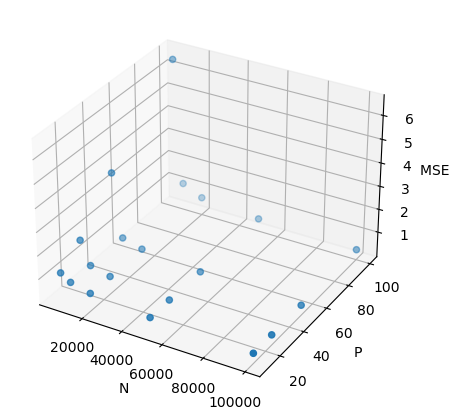

In [9]:
fig = plt.figure(figsize=(12, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s11mean.N, s11mean.P, s11mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSE ')
#ax.set_title('Simulation 1: 2 variables in mean - 0 variables in variance')

Text(0.5, 0, 'MSE ')

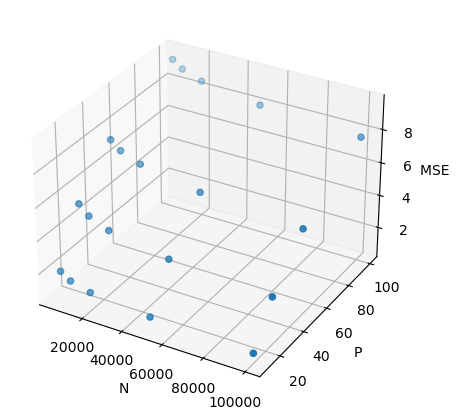

In [10]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s12mean.N, s12mean.P, s12mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSE ')
#ax.set_title('Simulation 1: 2 variables in mean - 0 variables in variance')

Text(0.5, 0, 'MSEV')

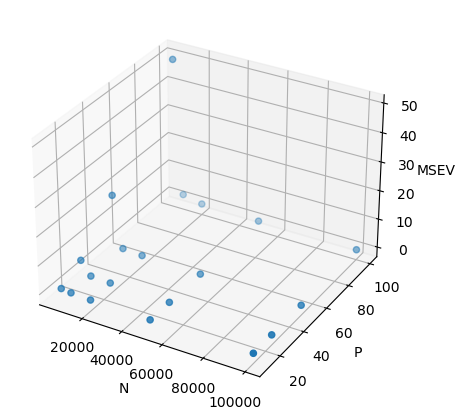

In [11]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s11mean.N, s11mean.P, s11mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 1: 2 variables in mean - 0 variables in variance')

Text(0.5, 0, 'MSEV')

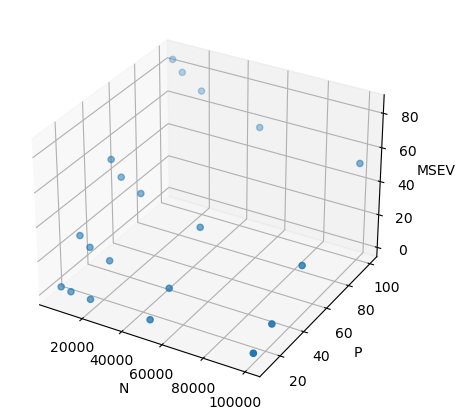

In [12]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s12mean.N, s12mean.P, s12mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 1: 2 variables in mean - 0 variables in variance')

In [14]:
s21 = pd.read_csv('data/lar2.csv')
s22 = pd.read_csv('data/lar2_no.csv')
s21mean = s21.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s22mean = s22.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s21mean

,N,P,MSEA,MSEV
0,5000,10,0.0387,14.3784
1,5000,25,0.0391,14.6363
2,5000,50,0.0332,15.6074
3,5000,100,0.0369,20.8082
4,10000,10,0.0183,13.1692
5,10000,25,0.0208,13.8363
6,10000,50,0.0196,14.4489
7,10000,100,0.0235,14.7330
8,20000,10,0.0155,11.2963
9,20000,25,0.0143,12.6701


In [15]:
s22mean

,N,P,MSEA,MSEV
0,5000,10,0.0367,13.7303
1,5000,25,0.0391,14.3761
2,5000,50,0.0332,15.8482
3,5000,100,0.0368,20.7268
4,10000,10,0.0180,12.0753
5,10000,25,0.0208,13.0871
6,10000,50,0.0196,13.9747
7,10000,100,0.0231,14.8806
8,20000,10,0.0142,10.1889
9,20000,25,0.0142,11.8467


In [16]:
p10_1 = s21mean.loc[s11mean['P'] == 10, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p25_1 = s21mean.loc[s11mean['P'] == 25, ['MSEA', 'MSEV']].reset_index(drop=True)
p50_1 = s21mean.loc[s11mean['P'] == 50, ['MSEA', 'MSEV']].reset_index(drop=True)
p100_1 = s21mean.loc[s11mean['P'] == 100, ['MSEA', 'MSEV']].reset_index(drop=True)

p10_2 = s22mean.loc[s12mean['P'] == 10, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p25_2 = s22mean.loc[s12mean['P'] == 25, ['MSEA', 'MSEV']].reset_index(drop=True)
p50_2 = s22mean.loc[s12mean['P'] == 50, ['MSEA', 'MSEV']].reset_index(drop=True)
p100_2 = s22mean.loc[s12mean['P'] == 100, ['MSEA', 'MSEV']].reset_index(drop=True)

df1 = pd.concat([p10_1, p25_1, p50_1, p100_1], axis=1)
df1.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df2 = pd.concat([p10_2, p25_2, p50_2, p100_2], axis=1)
df2.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df = pd.concat([df1, df2], axis=0)
latex = df.style.format(precision=4).format_index(
    axis=1, formatter="${}$".format).hide(axis=0).to_latex(
        position='bt!',
        position_float="centering",
        hrules=False, 
        label="tab:med1", 
        column_format='c|c|cc|cc|cc|cc|cc',
        caption="Performance evaluations in scenario 3 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.",
)
print(latex)

ValueError: Length mismatch: Expected axis has 3 elements, new values have 5 elements

Text(0.5, 0, 'MSEA')

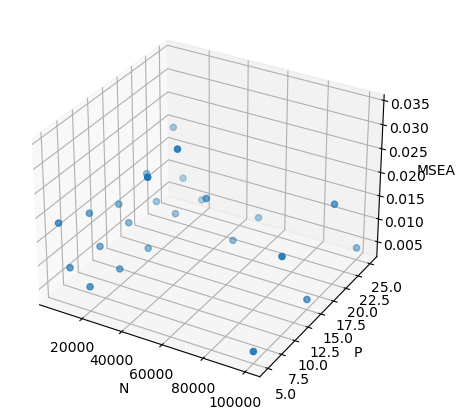

In [315]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s21mean.N, s21mean.P, s21mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEA')
#ax.set_title('Simulation 2: 0 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEA')

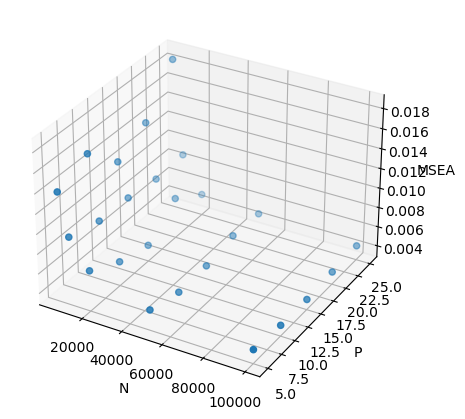

In [316]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s22mean.N, s22mean.P, s22mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEA')
#ax.set_title('Simulation 2: 0 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEV')

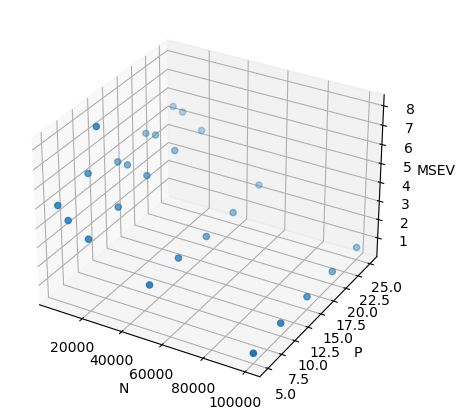

In [317]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s21mean.N, s21mean.P, s21mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 2: 0 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEV')

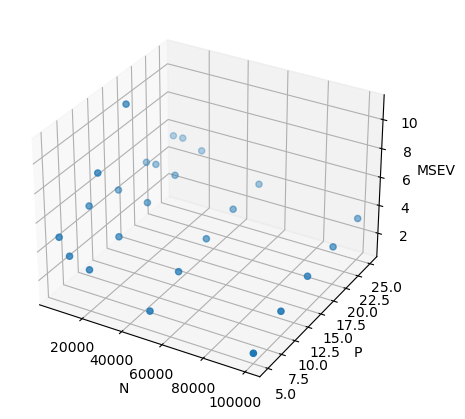

In [318]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s22mean.N, s22mean.P, s22mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 2: 0 variables in mean - 1 variable in variance')

In [22]:

s31 = pd.read_csv('data/lar3.csv')
s311 = pd.read_csv('data/lar3_50.csv')
s31 = pd.concat([s31, s311])
s32 = pd.read_csv('data/lar3_no.csv')
s31mean = s31.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s32mean = s32.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s31mean


,N,P,MSEA,MSEV
0,5000,10,0.9578,6.1629
1,5000,25,1.6626,10.9807
2,5000,50,2.6269,14.1726
3,5000,100,4.0297,25.7819
4,10000,10,0.5283,3.2111
5,10000,25,0.5316,3.4864
6,10000,50,0.5681,3.8378
7,10000,100,0.7101,4.4814
8,20000,10,0.3722,2.2244
9,20000,25,0.3700,2.2088


In [19]:
s32mean

,N,P,MSEA,MSEV
0,5000,10,1.7833,6.0482
1,5000,25,3.9554,18.5633
2,5000,50,5.5883,34.3815
3,5000,100,7.0232,51.6747
4,10000,10,1.4065,4.6117
5,10000,25,3.4756,14.5157
6,10000,50,5.1919,28.8882
7,10000,100,6.6454,49.9896
8,20000,10,1.1528,3.7377
9,20000,25,3.0854,11.5636


In [23]:
p10_1 = s31mean.loc[s11mean['P'] == 10, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p25_1 = s31mean.loc[s11mean['P'] == 25, ['MSEA', 'MSEV']].reset_index(drop=True)
p50_1 = s31mean.loc[s11mean['P'] == 50, ['MSEA', 'MSEV']].reset_index(drop=True)
p100_1 = s31mean.loc[s11mean['P'] == 100, ['MSEA', 'MSEV']].reset_index(drop=True)

p10_2 = s32mean.loc[s12mean['P'] == 10, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p25_2 = s32mean.loc[s12mean['P'] == 25, ['MSEA', 'MSEV']].reset_index(drop=True)
p50_2 = s32mean.loc[s12mean['P'] == 50, ['MSEA', 'MSEV']].reset_index(drop=True)
p100_2 = s32mean.loc[s12mean['P'] == 100, ['MSEA', 'MSEV']].reset_index(drop=True)

df1 = pd.concat([p10_1, p25_1, p50_1, p100_1], axis=1)
df1.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df2 = pd.concat([p10_2, p25_2, p50_2, p100_2], axis=1)
df2.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df = pd.concat([df1, df2], axis=0)
latex = df.style.format(precision=4).format_index(
    axis=1, formatter="${}$".format).hide(axis=0).to_latex(
        position='bt!',
        position_float="centering",
        hrules=False, 
        label="tab:med1", 
        column_format='c|c|cc|cc|cc|cc|cc',
        caption="Performance evaluations in scenario 3 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.",
)
print(latex)

\begin{table}[bt!]
\centering
\caption{Performance evaluations in scenario 3 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.}
\label{tab:med1}
\begin{tabular}{c|c|cc|cc|cc|cc|cc}
$N$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ \\
5000 & 0.9578 & 6.1629 & 1.6626 & 10.9807 & 2.6269 & 14.1726 & 4.0297 & 25.7819 \\
10000 & 0.5283 & 3.2111 & 0.5316 & 3.4864 & 0.5681 & 3.8378 & 0.7101 & 4.4814 \\
20000 & 0.3722 & 2.2244 & 0.3700 & 2.2088 & 0.3737 & 2.5839 & 0.3734 & 2.6613 \\
50000 & 0.2502 & 0.4853 & 0.2496 & 0.4908 & 0.2510 & 0.5408 & 0.2557 & 0.6130 \\
100000 & 0.1892 & 0.2023 & 0.1886 & 0.2080 & 0.1881 & 0.2998 & 0.1914 & 0.4898 \\
5000 & 1.7833 & 6.0482 & 3.9554 & 18.5633 & 5.5883 & 34.3815 & 7.0232 & 51.6747 \\
10000 & 1.4065 & 4.6117 & 3.4756 & 14.5157 & 5.1919 & 28.8882 & 6.6454 & 49.989

Text(0.5, 0, 'MSEA')

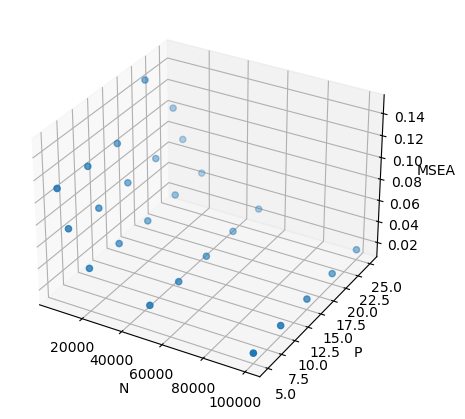

In [322]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s31mean.N, s31mean.P, s31mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEA')
#ax.set_title('Simulation 3: 2 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEA')

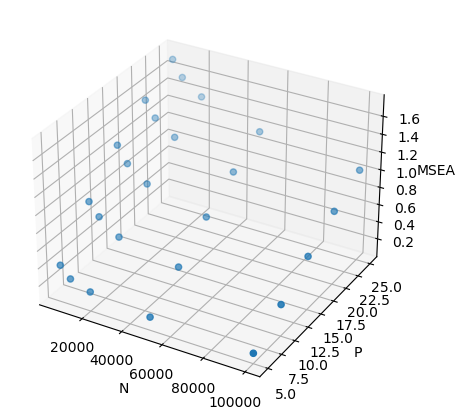

In [323]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s32mean.N, s32mean.P, s32mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEA')
#ax.set_title('Simulation 3: 2 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEV')

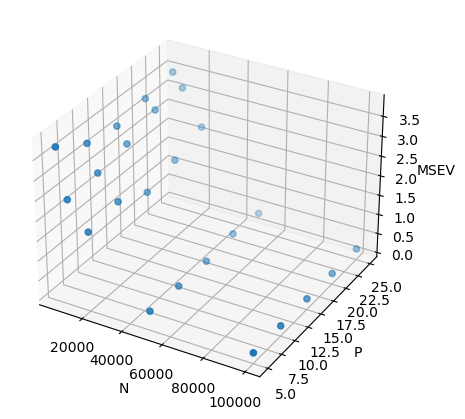

In [324]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s31mean.N, s31mean.P, s31mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 3: 2 variables in mean - 1 variable in variance')

Text(0.5, 0, 'MSEV')

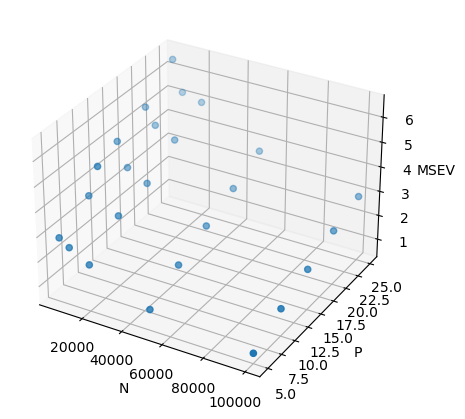

In [325]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s32mean.N, s32mean.P, s32mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 3: 2 variables in mean - 1 variable in variance')

In [24]:
s41 = pd.read_csv('data/lar4.csv')
s42 = pd.read_csv('data/lar4_no.csv')
s41mean = s41.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s42mean = s42.groupby(['N', 'P'])[['MSEA', 'MSEV']].mean().reset_index()
s41mean


FileNotFoundError: [Errno 2] No such file or directory: 'data/lar4.csv'

In [333]:
s42mean

,N,P,MSEA,MSEV
0,5000,5,0.6203,4.7061
1,5000,10,1.3012,6.5364
2,5000,15,1.8392,8.5037
3,5000,20,2.2675,10.2376
4,5000,25,2.6103,11.7655
5,10000,5,0.4262,3.2400
6,10000,10,1.0603,5.3889
7,10000,15,1.5702,6.9535
8,10000,20,2.0009,8.2738
9,10000,25,2.3419,10.0465


In [334]:
p10_1 = s11mean.loc[s11mean['P'] == 10, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p25_1 = s11mean.loc[s11mean['P'] == 25, ['MSEA', 'MSEV']].reset_index(drop=True)
p50_1 = s11mean.loc[s11mean['P'] == 50, ['MSEA', 'MSEV']].reset_index(drop=True)
p100_1 = s11mean.loc[s11mean['P'] == 100, ['MSEA', 'MSEV']].reset_index(drop=True)

p10_2 = s12mean.loc[s12mean['P'] == 10, ['N', 'MSEA', 'MSEV']].reset_index(drop=True)
p25_2 = s12mean.loc[s12mean['P'] == 25, ['MSEA', 'MSEV']].reset_index(drop=True)
p50_2 = s12mean.loc[s12mean['P'] == 50, ['MSEA', 'MSEV']].reset_index(drop=True)
p100_2 = s12mean.loc[s12mean['P'] == 100, ['MSEA', 'MSEV']].reset_index(drop=True)

df1 = pd.concat([p10_1, p25_1, p50_1, p100_1], axis=1)
df1.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df2 = pd.concat([p10_2, p25_2, p50_2, p100_2], axis=1)
df2.index = pd.MultiIndex.from_tuples([
    ("FS", "1"), ("FS", "2"), ("FS", "3"), ("FS", "4"), ("FS", "5")
])

df = pd.concat([df1, df2], axis=0)
latex = df.style.format(precision=4).format_index(
    axis=1, formatter="${}$".format).hide(axis=0).to_latex(
        position='bt!',
        position_float="centering",
        hrules=False, 
        label="tab:med1", 
        column_format='c|c|cc|cc|cc|cc|cc',
        caption="Performance evaluations in scenario 3 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.",
)
print(latex)

\begin{table}[bt!]
\centering
\caption{Performance evaluations in scenario 3 of the estimators $\overline{x}$ and $\hat{v}$ for the different K-NN graph settings described in the text with and without feature selection. We report the mean squared error averaging over 100 Monte Carlo simulations.}
\label{tab:med4}
\begin{tabular}{c|c|cc|cc|cc|cc|cc}
$N$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ & $MSEA$ & $MSEV$ \\
5000 & 0.4595 & 4.7770 & 0.5949 & 5.9733 & 0.5122 & 5.6589 & 0.7144 & 6.4106 & 0.7216 & 7.0355 \\
10000 & 0.2039 & 3.6149 & 0.1970 & 4.7286 & 0.2016 & 4.9257 & 0.1999 & 5.0850 & 0.2105 & 5.2470 \\
20000 & 0.1379 & 4.1692 & 0.1376 & 4.0456 & 0.1290 & 4.5650 & 0.1352 & 4.4326 & 0.1407 & 4.7055 \\
50000 & 0.0817 & 2.1319 & 0.0806 & 2.1220 & 0.0806 & 2.1025 & 0.0811 & 2.2774 & 0.0796 & 2.2736 \\
100000 & 0.0599 & 0.6240 & 0.0583 & 0.5797 & 0.0595 & 0.6316 & 0.0592 & 0.6167 & 0.0601 & 0.6136 \\
5000 & 0.6203 & 4.7061 & 1.3012 & 6.5364 & 1.8392 & 8.503

Text(0.5, 0, 'MSEA')

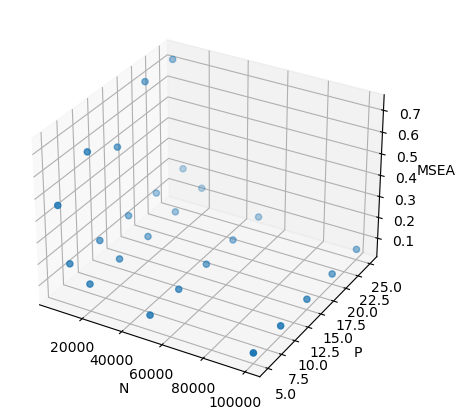

In [329]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s41mean.N, s41mean.P, s41mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEA')
#ax.set_title('Simulation 4: 2 variables in mean - 0 variables in variance - No feature selection')

Text(0.5, 0, 'MSEA')

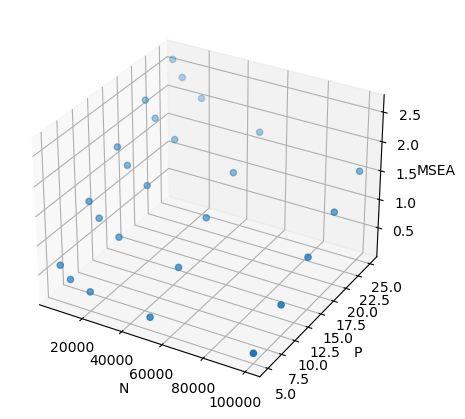

In [330]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s42mean.N, s42mean.P, s42mean.MSEA)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEA')
#ax.set_title('Simulation 4: 2 variables in mean - 0 variables in variance - No feature selection')

Text(0.5, 0, 'MSEV')

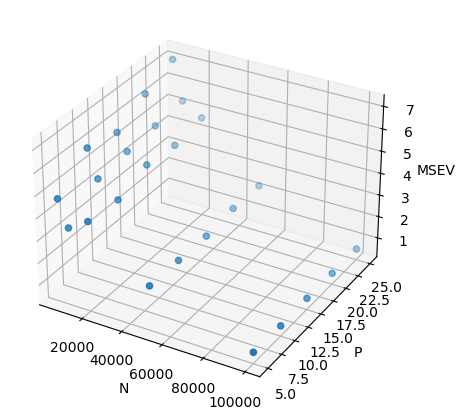

In [331]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s41mean.N, s41mean.P, s41mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 4: 2 variables in mean - 0 variables in variance - No feature selection')

Text(0.5, 0, 'MSEV')

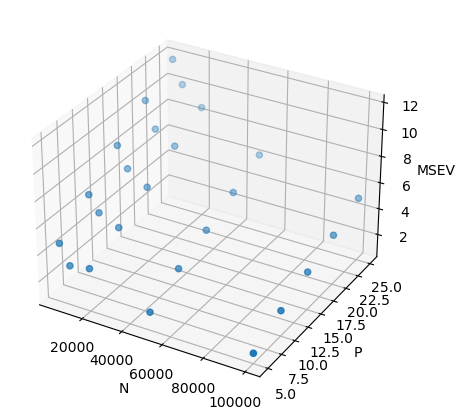

In [332]:
fig = plt.figure(figsize=(6, 4))  
ax = fig.add_subplot(projection='3d')
ax.scatter(s42mean.N, s42mean.P, s42mean.MSEV)
ax.set_xlabel('N')
ax.set_ylabel('P')
ax.set_zlabel('MSEV')
#ax.set_title('Simulation 4: 2 variables in mean - 0 variables in variance - No feature selection')